In [11]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage.feature import hog
from tqdm import tqdm
from sklearn.utils import shuffle

from skimage.feature import hog, local_binary_pattern

In [12]:
# Use project-local PetImages folder
DATADIR = os.path.join(os.getcwd(), "PetImages")

CATEGORIES = ["Dog", "Cat"]
IMG_SIZE = 128  # Image size after resizing

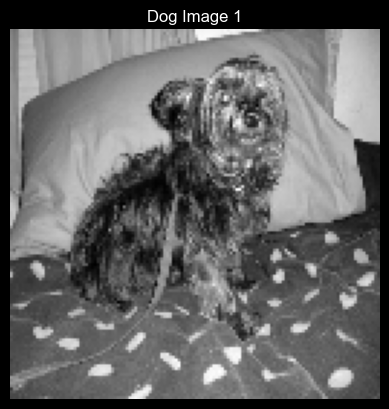

Dimensions = (128, 128)


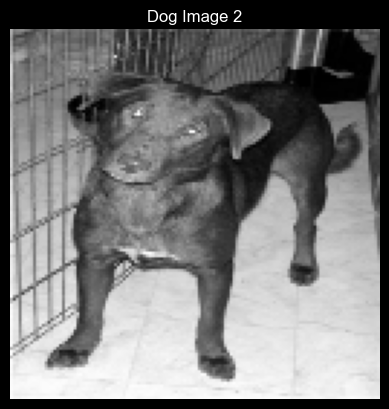

Dimensions = (128, 128)


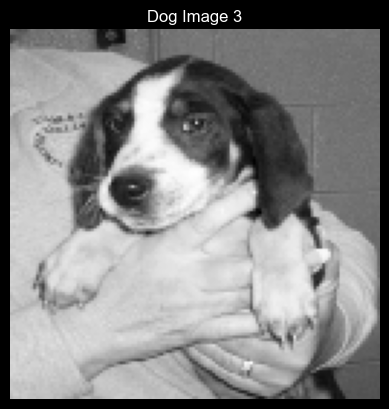

Dimensions = (128, 128)


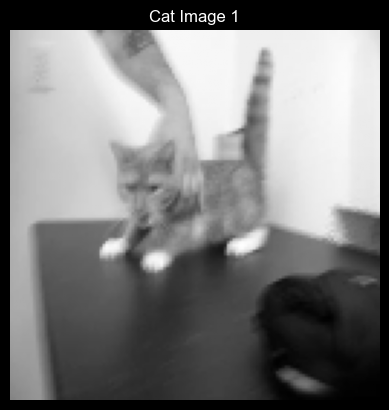

Dimensions = (128, 128)


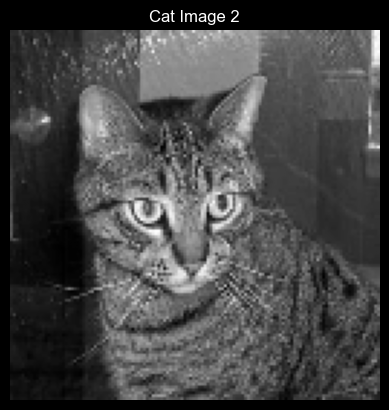

Dimensions = (128, 128)


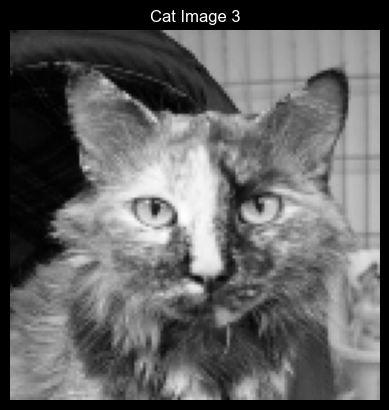

Dimensions = (128, 128)

Total processed images = 24997


In [13]:
DATADIR = 'PetImages'
CATEGORIES = ['Dog', 'Cat']

IMG_SIZE = 128

processed_images = []
labels = []

for label, category in enumerate(CATEGORIES):

    path = os.path.join(DATADIR, category)

    x = 0

    for img in os.listdir(path):

        img_path = os.path.join(path, img)

        # Convert to grayscale
        img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img_array is None:
            continue

        # Resize image
        new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))

        # Store ALL processed images
        processed_images.append(new_array)

         # Store label: Dog = 0, Cat = 1
        labels.append(label)

        # Show only first 3 images
        if x < 3:

            plt.imshow(new_array, cmap='gray')
            plt.title(f"{category} Image {x+1}")
            plt.axis("off")
            plt.show()

            print("Dimensions =", new_array.shape)

        x += 1

print("\nTotal processed images =", len(processed_images))

In [14]:
hog_processed_images = []
HOG_CONFIG = {
    "orientations": 9,
    "pixels_per_cell": (32, 32),
    "cells_per_block": (2, 2),
    "block_norm": "L2-Hys",
    "visualize": False
}
for image in tqdm(processed_images, desc="Extracting HOG Features"):

    features = hog(
        image,
        orientations=HOG_CONFIG["orientations"],
        pixels_per_cell=HOG_CONFIG["pixels_per_cell"],
        cells_per_block=HOG_CONFIG["cells_per_block"],
        block_norm=HOG_CONFIG["block_norm"],
        feature_vector=True
    )

    hog_processed_images.append(features)


hog_processed_images = np.array(hog_processed_images)
labels = np.array(labels)

print("Number of processed images:", len(processed_images))
print("Number of HOG vectors:", len(hog_processed_images))
print("One HOG vector shape:", hog_processed_images[0].shape)
print("Labels shape:", labels.shape)


Extracting HOG Features: 100%|██████████| 24997/24997 [00:28<00:00, 871.61it/s]

Number of processed images: 24997
Number of HOG vectors: 24997
One HOG vector shape: (324,)
Labels shape: (24997,)


In [15]:
LBP_CONFIG = {
    "P": 8,           # neighbours on circle — captures 8-connected texture
    "R": 1,           # radius — fine-grained local texture
    "method": "uniform",  # uniform patterns (~90% of natural images)
    "n_bins": 10,     # histogram bins after normalisation
}

def extract_lbp(image, config=LBP_CONFIG):
    lbp_map = local_binary_pattern(image, P=config["P"], R=config["R"], method=config["method"])
    hist, _ = np.histogram(lbp_map.ravel(), bins=config["n_bins"], range=(0, config["n_bins"]))
    hist = hist.astype(np.float32)
    if hist.sum() > 0:
        hist /= hist.sum()
    return hist

# Concatenate HOG + LBP using numpy.hstack
# HOG captures shape/edges; LBP captures local texture (fur, coat patterns)
final_features = np.array([
    np.hstack([hog_vec, extract_lbp(img)])
    for hog_vec, img in tqdm(zip(hog_processed_images, processed_images),
                             total=len(processed_images), desc="Adding LBP")
])

print("HOG vector length :", hog_processed_images[0].shape[0])
print("LBP vector length  :", LBP_CONFIG["n_bins"])
print("Final feature shape:", final_features.shape)
print("Labels shape:", labels.shape)

Adding LBP: 100%|██████████| 24997/24997 [00:33<00:00, 754.25it/s]

HOG vector length : 324
LBP vector length  : 10
Final feature shape: (24997, 334)
Labels shape: (24997,)


In [16]:
#Shuffling the dataset to avoid testing only one type of image

from sklearn.utils import shuffle

# Shuffle features and labels together
X, y = shuffle(final_features, labels, random_state=42)

# Check first 10 labels after shuffling
print(y[:10])

[0 1 0 1 1 0 0 1 0 0]


In [17]:
# Split data: 80% for Training , 20% for Testing (exam)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, stratify=y,random_state=42)

print(len(X_train)) #Trains on 19997 (80%) images out of the total 24997
print(len(X_test))  #Tets on shuffled 5000 (20%) images

19997
5000
